# **Data Loading & Preprocessing**



1.   Loading the dataset
2.   Separating features and target
3.   Train-Test split(80% training, 20% testing)
4.   Feature scaling



In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#1.
df = pd.read_csv('/content/sample_data/mobile_price_classification.csv')

#2.
X = df.drop('price_range', axis=1)
y = df['price_range']

#3.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#4.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training shape: {X_train_scaled.shape}")
print(f"Testing shape:  {X_test_scaled.shape}")

Training shape: (1600, 20)
Testing shape:  (400, 20)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   battery_power   2000 non-null   int64  
 1   bluetooth       2000 non-null   int64  
 2   clock_speed     2000 non-null   float64
 3   dual_sim        2000 non-null   int64  
 4   front_cam       2000 non-null   int64  
 5   4G              2000 non-null   int64  
 6   int_memory      2000 non-null   int64  
 7   m_dep           2000 non-null   float64
 8   mobile_wt       2000 non-null   int64  
 9   n_cores         2000 non-null   int64  
 10  primary_camera  2000 non-null   int64  
 11  px_height       2000 non-null   int64  
 12  px_width        2000 non-null   int64  
 13  ram             2000 non-null   int64  
 14  sc_h            2000 non-null   int64  
 15  sc_w            2000 non-null   int64  
 16  talk_time       2000 non-null   int64  
 17  three_g         2000 non-null   i

# **Exploratory Data Analysis**



1.   Feature Importance Plot
2.   Ram vs Price category distribution
3.   Correlation heatmap of top features



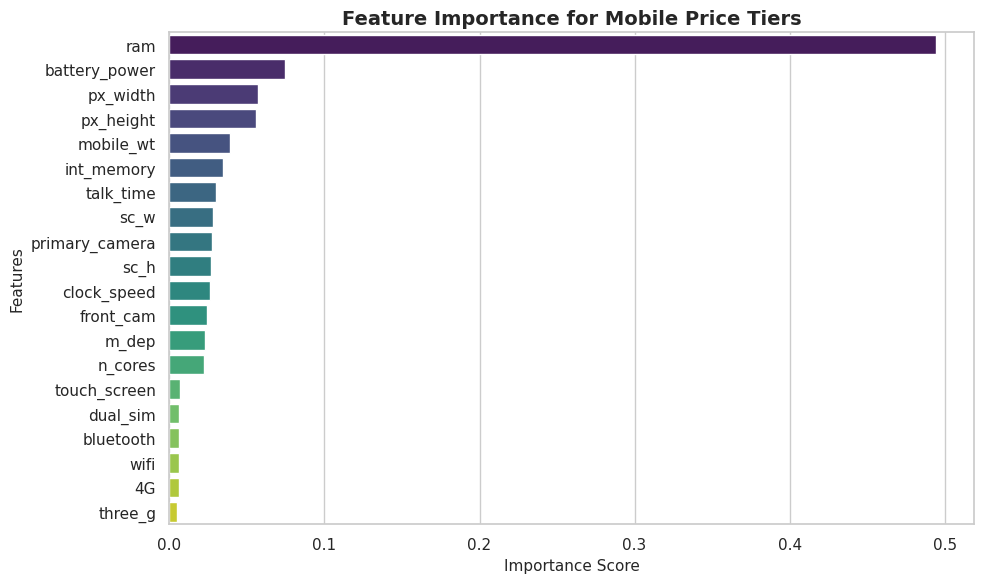

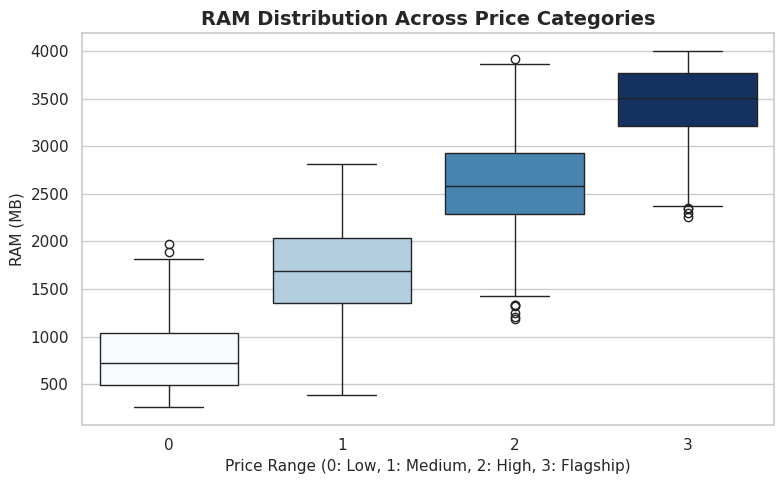

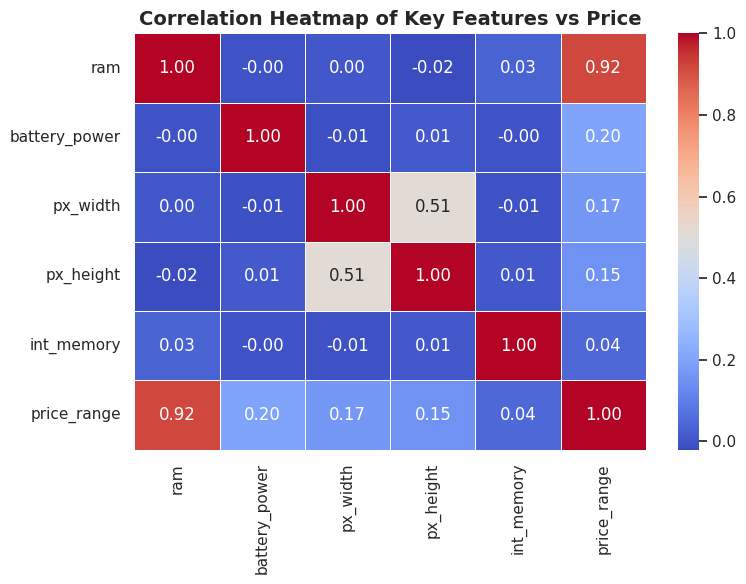

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid")

#1.
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis')
plt.title('Feature Importance for Mobile Price Tiers', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.tight_layout()
plt.show()

print("\n")
#2.
plt.figure(figsize=(8, 5))
sns.boxplot(x='price_range', y='ram', data=df,hue='price_range', palette='Blues', legend=False)
plt.title('RAM Distribution Across Price Categories', fontsize=14, fontweight='bold')
plt.xlabel('Price Range (0: Low, 1: Medium, 2: High, 3: Flagship)', fontsize=11)
plt.ylabel('RAM (MB)', fontsize=11)
plt.tight_layout()
plt.show()

print("\n")
#3.
top_features = ['ram', 'battery_power', 'px_width', 'px_height', 'int_memory', 'price_range']
plt.figure(figsize=(8, 6))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Key Features vs Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **Baseline Artificial Neural Network**



1.   One-hot encoding target labels
2.   Defining the baseline neural network architecture
3.   Compliling the model
4.   Training the neural network
5.   Evaluating model performance



In [3]:
import tensorflow as tf

#1.
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=4)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=4)

#2.
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(4, activation='softmax')
])

#3.
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#4.
history_baseline = baseline_model.fit(
    X_train_scaled, y_train_cat,
    epochs=60,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

#5.
loss, accuracy = baseline_model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"Baseline Test Loss: {loss:.4f}")
print(f"Baseline Test Accuracy: {accuracy * 100:.2f}%")

Baseline Test Loss: 0.1519
Baseline Test Accuracy: 94.00%


# **Hyperparameter Tuning**



1.   Defining the Hyperparameter search space
2.   Inializing the ANN classifier
3.   Configuring GridSearch cross validation
4.   Extracting and displaying the best parameter scores



In [4]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

#1.
param_grid = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [300]
}

#2.
mlp = MLPClassifier(random_state=42)

#3.
grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

#4.
print("Best Hyperparameters:")
for param, val in grid_search.best_params_.items():
    print(f" - {param}: {val}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Hyperparameters:
 - activation: tanh
 - alpha: 0.0001
 - hidden_layer_sizes: (128, 64)
 - learning_rate_init: 0.001
 - max_iter: 300
 - solver: adam
Best Cross-Validation Accuracy: 95.69%


# **Model Evaluation & Visualizing Performance Metrics**



1.   Extracting the best model
2.   Generating predictions on test data
3.   Printing overall testing accuracy
4.   Displaying classification report
5.   Confusion matrix of tuned neural network classifier



Final Tuned Neural Network Test Accuracy: 95.75%

Classification Metrics:
                precision    recall  f1-score   support

      Low Cost       0.97      0.98      0.98       100
   Medium Cost       0.96      0.93      0.94       100
     High Cost       0.93      0.95      0.94       100
Very High Cost       0.97      0.97      0.97       100

      accuracy                           0.96       400
     macro avg       0.96      0.96      0.96       400
  weighted avg       0.96      0.96      0.96       400



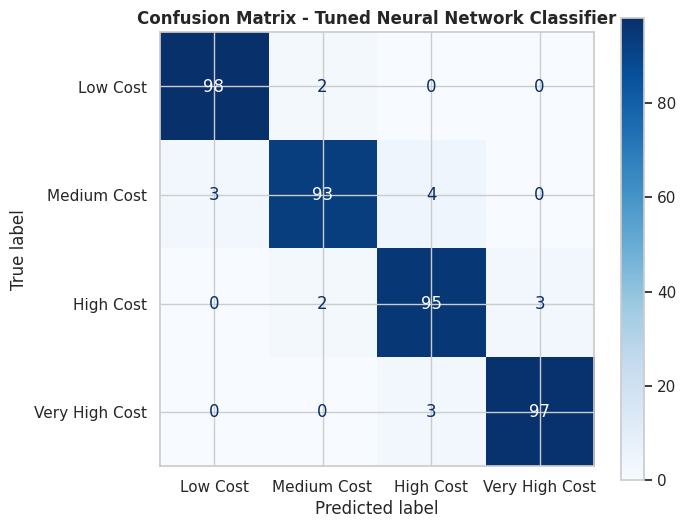

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

#1.
best_ann_model = grid_search.best_estimator_

#2.
y_pred = best_ann_model.predict(X_test_scaled)

#3.
test_acc = best_ann_model.score(X_test_scaled, y_test)
print(f"Final Tuned Neural Network Test Accuracy: {test_acc * 100:.2f}%\n")

#4.
class_names = ['Low Cost', 'Medium Cost', 'High Cost', 'Very High Cost']
print("Classification Metrics:")
print(classification_report(y_test, y_pred, target_names=class_names))

#5.
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix - Tuned Neural Network Classifier", fontsize=12, fontweight='bold')
plt.show()

### RAM is the single most important factor determining a mobile phone's price range, with higher RAM directly pushing a device into premium and flagship tiers. Other hardware features like battery capacity and screen resolution play a secondary role, while parameters like camera megapixels and SIM capabilities have almost no impact on pricing. Using these features, tuned neural network achieved over 95% accuracy in predicting price categories